# 01 - Data Exploration
Elvara Health | Early Sepsis Warning & Deterioration System

Loads the five raw tables, profiles data quality, cleans/preprocesses them, and runs EDA
to understand the relationship between vitals/labs and sepsis risk.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 4)

## 2. Load Dataset
CSV files are expected in the same folder as this notebook.

In [3]:
patients = pd.read_csv('../data/raw/patients.csv', parse_dates=['registration_date'])
vitals = pd.read_csv('../data/raw/vital_signs.csv', parse_dates=['timestamp'])
history = pd.read_csv('../data/raw/clinical_history.csv')
labs = pd.read_csv('../data/raw/laboratory_results.csv', parse_dates=['timestamp'])
outcomes = pd.read_csv('../data/raw/sepsis_outcomes.csv', parse_dates=['diagnosis_time'])

tables = {'patients': patients, 'vitals': vitals, 'history': history,
          'labs': labs, 'outcomes': outcomes}
for name, df in tables.items():
    print(f'{name:10s} shape={df.shape}')

patients   shape=(600, 5)
vitals     shape=(11807, 8)
history    shape=(1449, 6)
labs       shape=(2430, 8)
outcomes   shape=(600, 6)


## 3. Dataset Overview

In [4]:
patients.head()

,patient_id,age,gender,medical_conditions,registration_date
0,1,66,Male,"Diabetes, Cancer (active)",2024-10-19
1,2,42,Female,"Diabetes, Chronic Kidney Disease, Immunosuppre...",2025-06-24
2,3,74,Male,Cancer (active),2024-02-28
3,4,77,Female,"Diabetes, Hypertension",2024-07-31
4,5,25,Female,NaN,2024-07-09


In [5]:
patients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   patient_id          600 non-null    int64         
 1   age                 600 non-null    int64         
 2   gender              600 non-null    object        
 3   medical_conditions  445 non-null    object        
 4   registration_date   600 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 23.6+ KB


In [6]:
vitals.describe().T

,count,mean,min,25%,50%,75%,max,std
observation_id,11807.0,5904.0,1.0,2952.5,5904.0,8855.5,11807.0,3408.531649
patient_id,11807.0,297.125858,1.0,149.0,294.0,444.0,600.0,172.006979
timestamp,11807,2025-01-05 03:10:59.588379648,2024-01-01 04:37:00,2024-07-09 02:07:30,2025-01-15 01:46:00,2025-07-11 20:25:30,2025-12-29 07:13:00,NaN
heart_rate,11490.0,79.892097,43.4,73.2,79.2,85.3,137.4,10.838351
temperature,11514.0,36.84276,34.52,36.55,36.82,37.09,40.25,0.51965
oxygen_saturation,11520.0,97.271389,86.4,96.6,97.4,98.2,100.0,1.555355
respiratory_rate,11519.0,16.543233,8.0,14.6,16.3,18.0,34.6,2.990542
blood_pressure,11545.0,121.214517,55.0,113.8,121.5,129.0,163.9,12.076626


In [7]:
labs.describe().T

,count,mean,min,25%,50%,75%,max,std
lab_id,2430.0,1215.5,1.0,608.25,1215.5,1822.75,2430.0,701.6249
patient_id,2430.0,298.609877,1.0,148.0,300.0,445.0,600.0,172.363294
timestamp,2430,2025-01-01 02:57:24.197530880,2024-01-01 12:52:00,2024-07-01 21:03:00,2025-01-10 09:40:00,2025-07-10 09:41:30,2025-12-28 16:48:00,NaN
white_cell_count,2359.0,7.814782,1.0,6.315,7.59,8.97,22.15,2.433649
crp,2370.0,12.306751,0.5,3.325,6.3,9.5,193.1,26.120474
lactate,2356.0,1.141698,0.3,0.8275,1.03,1.23,5.65,0.66575
creatinine,2347.0,0.942833,0.3,0.76,0.91,1.08,2.38,0.286345
platelet_count,2357.0,254.255834,55.0,224.0,255.0,285.0,388.0,46.140953


In [8]:
print('Sepsis prevalence:', outcomes['sepsis_event'].mean().round(3))
outcomes['sepsis_event'].value_counts()

Sepsis prevalence: 0.12


sepsis_event
False    528
True      72
Name: count, dtype: int64

## 4. Data Quality Assessment

In [9]:
def missing_report(df, name):
    miss = df.isna().mean().mul(100).round(2)
    miss = miss[miss > 0]
    if len(miss):
        print(f'--- {name} ---')
        print(miss.to_string())

for name, df in tables.items():
    missing_report(df, name)

--- patients ---
medical_conditions    25.83
--- vitals ---
heart_rate           2.68
temperature          2.48
oxygen_saturation    2.43
respiratory_rate     2.44
blood_pressure       2.22
--- history ---
diagnosis_history      2.62
medication_history     9.45
treatment_history     14.56
--- labs ---
white_cell_count    2.92
crp                 2.47
lactate             3.05
creatinine          3.42
platelet_count      3.00
--- outcomes ---
diagnosis_time    88.0


In [ ]:
for name, df in tables.items():
    print(f"\n{name}")
    negatives = (df < 0).sum()

    print("Negative values by field:")
    print(negatives[negatives > 0])

In [10]:
# Duplicate rows
for name, df in tables.items():
    print(name, 'duplicate rows:', df.duplicated().sum())

patients duplicate rows: 0
vitals duplicate rows: 0
history duplicate rows: 0
labs duplicate rows: 0
outcomes duplicate rows: 0


In [11]:
# Referential integrity: every FK patient_id must exist in patients
valid_ids = set(patients['patient_id'])
for name, df in [('vitals', vitals), ('history', history), ('labs', labs), ('outcomes', outcomes)]:
    orphans = (~df['patient_id'].isin(valid_ids)).sum()
    print(name, 'orphan patient_id rows:', orphans)

vitals orphan patient_id rows: 0
history orphan patient_id rows: 0
labs orphan patient_id rows: 0
outcomes orphan patient_id rows: 0


In [12]:
# Plausible range check on vitals/labs
ranges = {
    'heart_rate': (30, 220), 'temperature': (32, 43), 'oxygen_saturation': (50, 100),
    'respiratory_rate': (5, 60), 'blood_pressure': (40, 220)
}
for col, (lo, hi) in ranges.items():
    bad = ((vitals[col] < lo) | (vitals[col] > hi)).sum()
    print(f'{col}: {bad} out-of-range values')

heart_rate: 0 out-of-range values
temperature: 0 out-of-range values
oxygen_saturation: 0 out-of-range values
respiratory_rate: 0 out-of-range values
blood_pressure: 0 out-of-range values


## 5. Handling & Cleaning the Dataset
- Missing vitals/labs: forward-fill within each patient's time-ordered readings, then
  fill any still-missing values with the column median (handles a patient's very first reading).
- Ensure correct dtypes and sort by patient/time.
- Drop exact duplicate rows if any.

In [13]:
vitals = vitals.drop_duplicates().sort_values(['patient_id', 'timestamp']).reset_index(drop=True)
labs = labs.drop_duplicates().sort_values(['patient_id', 'timestamp']).reset_index(drop=True)

vital_cols = ['heart_rate', 'temperature', 'oxygen_saturation', 'respiratory_rate', 'blood_pressure']
lab_cols = ['white_cell_count', 'crp', 'lactate', 'creatinine', 'platelet_count']

vitals[vital_cols] = vitals.groupby('patient_id')[vital_cols].transform(lambda s: s.ffill())
vitals[vital_cols] = vitals[vital_cols].fillna(vitals[vital_cols].median())

labs[lab_cols] = labs.groupby('patient_id')[lab_cols].transform(lambda s: s.ffill())
labs[lab_cols] = labs[lab_cols].fillna(labs[lab_cols].median())

print('Remaining missing values -> vitals:', vitals[vital_cols].isna().sum().sum(),
      '| labs:', labs[lab_cols].isna().sum().sum())

Remaining missing values -> vitals: 0 | labs: 0


In [14]:
# Save cleaned tables for use in 02_feature_engineering.ipynb
patients.to_csv('patients_clean.csv', index=False)
vitals.to_csv('vital_signs_clean.csv', index=False)
labs.to_csv('laboratory_results_clean.csv', index=False)
history.to_csv('clinical_history_clean.csv', index=False)
outcomes.to_csv('sepsis_outcomes_clean.csv', index=False)
print('Cleaned tables saved.')

Cleaned tables saved.


## 6. Exploratory Data Analysis

### 6.1 Sepsis prevalence

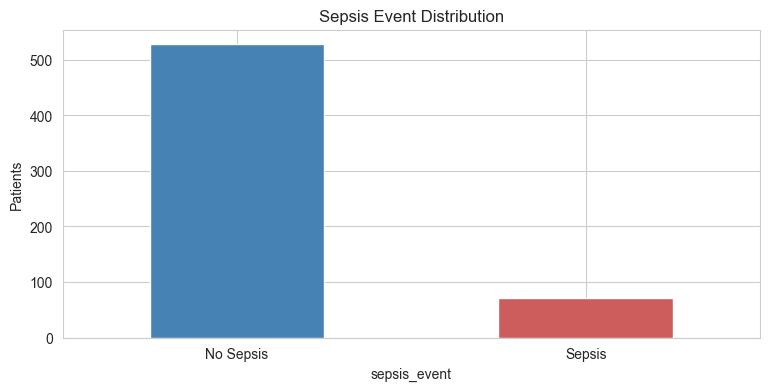

In [15]:
outcomes['sepsis_event'].value_counts().plot(kind='bar', color=['steelblue', 'indianred'])
plt.title('Sepsis Event Distribution')
plt.xticks([0, 1], ['No Sepsis', 'Sepsis'], rotation=0)
plt.ylabel('Patients')
plt.show()

### 6.2 Age distribution by sepsis outcome

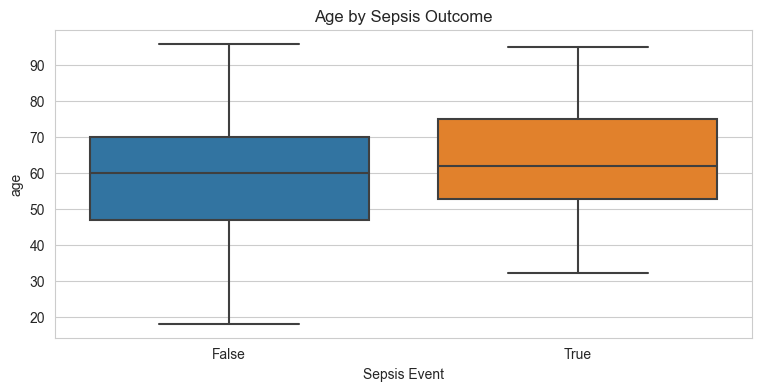

In [16]:
merged_pat = patients.merge(outcomes[['patient_id', 'sepsis_event']], on='patient_id')
sns.boxplot(data=merged_pat, x='sepsis_event', y='age')
plt.title('Age by Sepsis Outcome')
plt.xlabel('Sepsis Event')
plt.show()

### 6.3 Vitals: sepsis vs non-sepsis readings

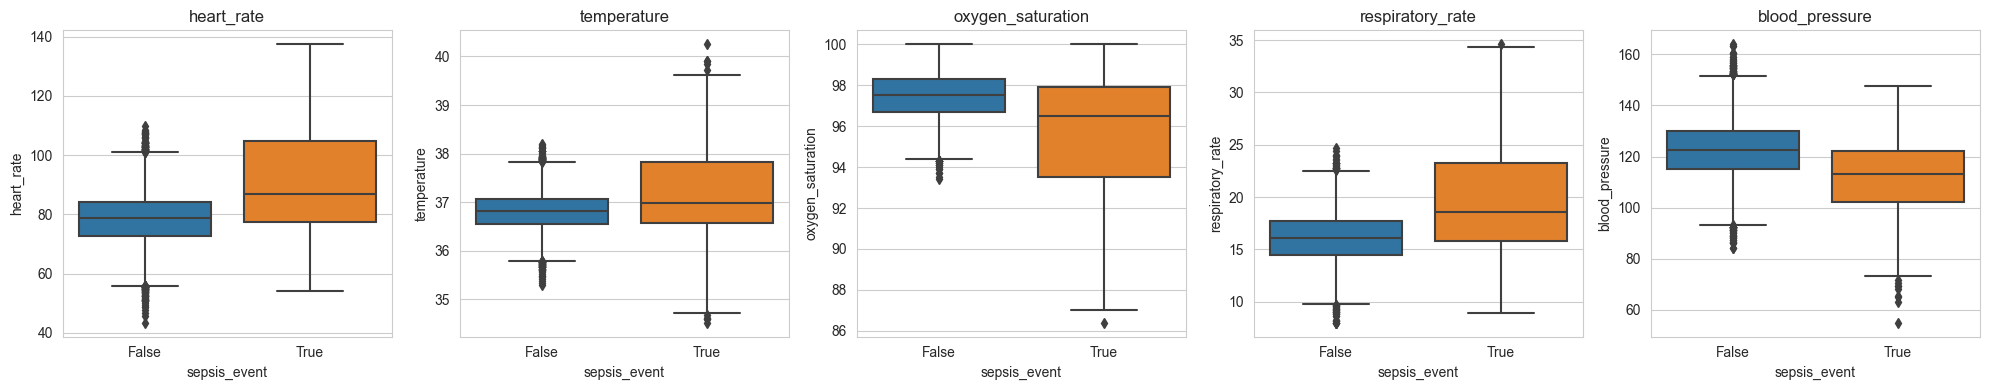

In [17]:
v = vitals.merge(outcomes[['patient_id', 'sepsis_event']], on='patient_id')
fig, axes = plt.subplots(1, len(vital_cols), figsize=(20, 4))
for ax, col in zip(axes, vital_cols):
    sns.boxplot(data=v, x='sepsis_event', y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

### 6.4 Labs: sepsis vs non-sepsis readings

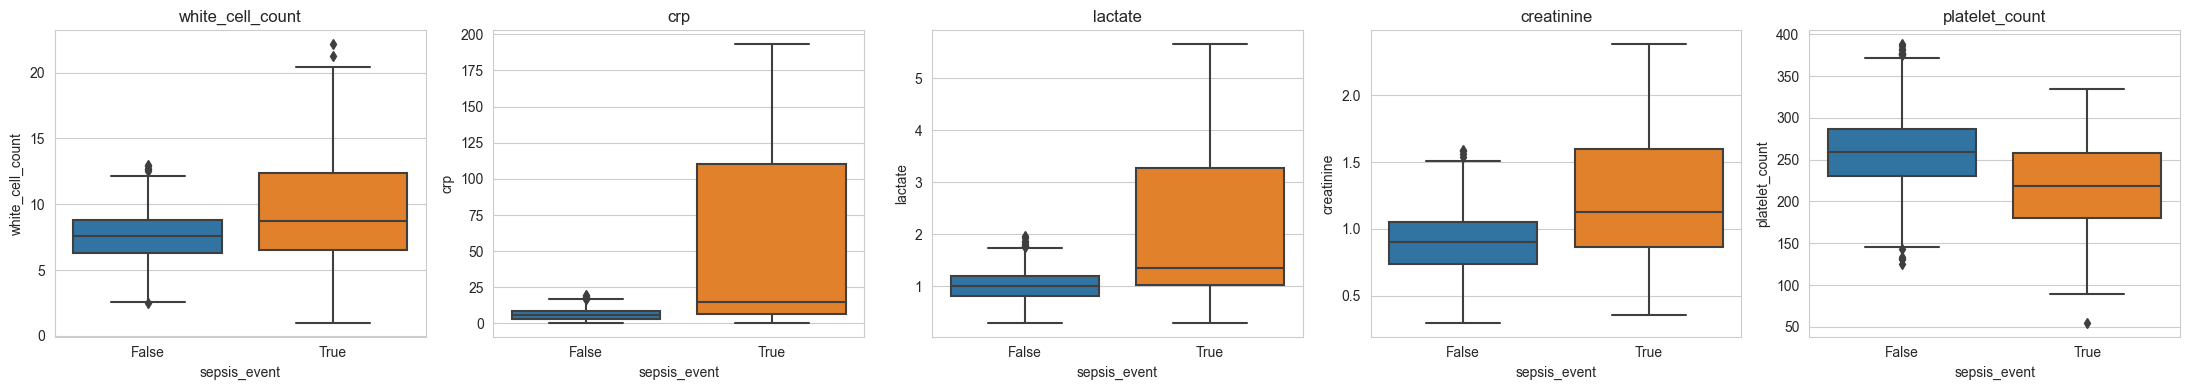

In [18]:
l = labs.merge(outcomes[['patient_id', 'sepsis_event']], on='patient_id')
fig, axes = plt.subplots(1, len(lab_cols), figsize=(22, 4))
for ax, col in zip(axes, lab_cols):
    sns.boxplot(data=l, x='sepsis_event', y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

### 6.5 Vitals trend before diagnosis (sepsis patients)
Average heart rate and oxygen saturation in the hours leading up to diagnosis.

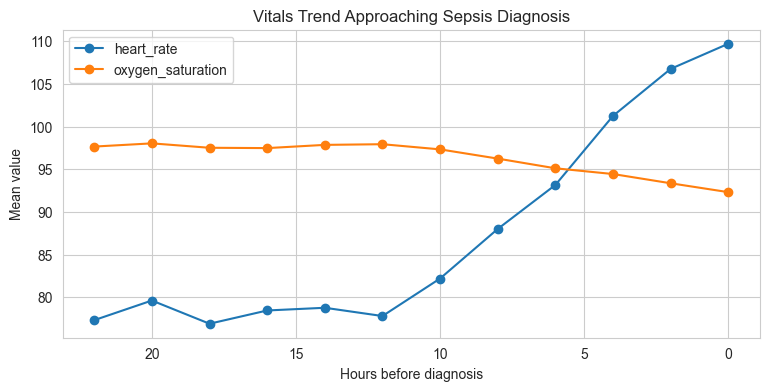

In [19]:
diag_map = outcomes.set_index('patient_id')['diagnosis_time'].to_dict()
sepsis_ids = outcomes.loc[outcomes['sepsis_event'], 'patient_id']

sv = vitals[vitals['patient_id'].isin(sepsis_ids)].copy()
sv['hrs_to_diag'] = (sv['patient_id'].map(diag_map) - sv['timestamp']).dt.total_seconds() / 3600
sv = sv[(sv['hrs_to_diag'] >= 0) & (sv['hrs_to_diag'] <= 24)]
sv['hr_bucket'] = (sv['hrs_to_diag'] // 2 * 2).astype(int)

trend = sv.groupby('hr_bucket')[['heart_rate', 'oxygen_saturation']].mean().sort_index(ascending=False)
trend.plot(marker='o')
plt.xlabel('Hours before diagnosis')
plt.ylabel('Mean value')
plt.title('Vitals Trend Approaching Sepsis Diagnosis')
plt.gca().invert_xaxis()
plt.show()

### 6.6 Correlation heatmap (vitals + labs, patient-level means)

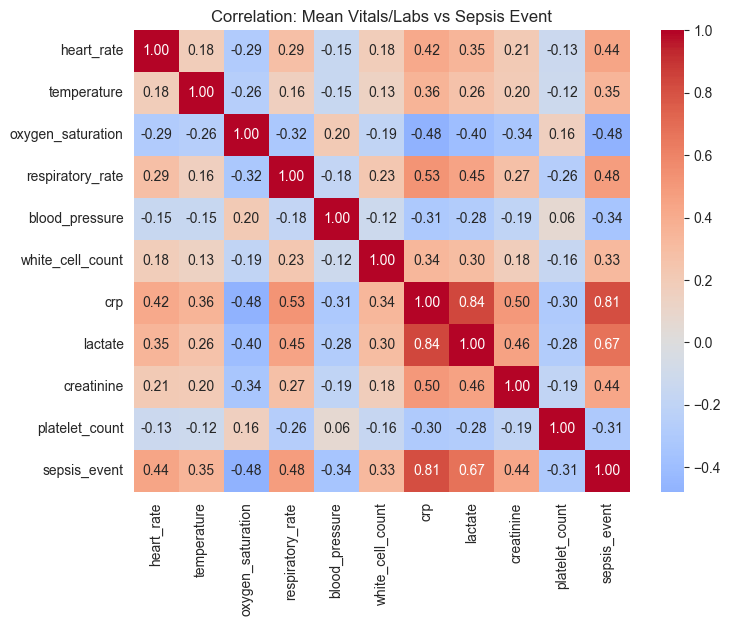

In [20]:
vital_means = vitals.groupby('patient_id')[vital_cols].mean()
lab_means = labs.groupby('patient_id')[lab_cols].mean()
feat = vital_means.join(lab_means).join(outcomes.set_index('patient_id')['sepsis_event'].astype(int))

plt.figure(figsize=(8, 6))
sns.heatmap(feat.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation: Mean Vitals/Labs vs Sepsis Event')
plt.show()

### 6.7 Comorbidity count vs sepsis

In [22]:
merged_pat["comorbidity_count"] = (
    merged_pat["medical_conditions"]
    .fillna("")
    .astype(str)
    .apply(
        lambda x: 0
        if not x.strip() or x.strip().lower() == "none"
        else len([item for item in x.split(",") if item.strip()])
    )
)

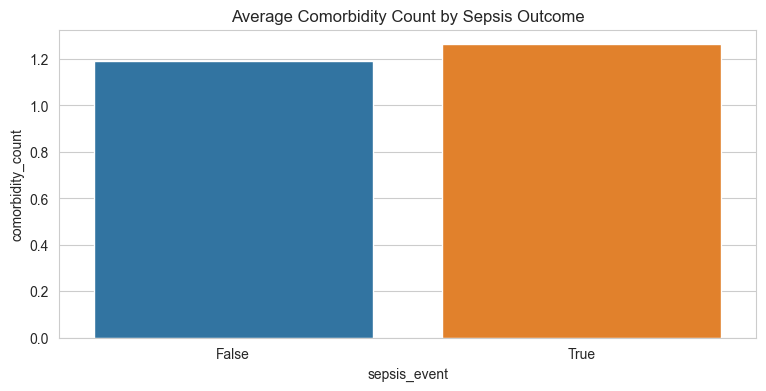

In [23]:
sns.barplot(data=merged_pat, x='sepsis_event', y='comorbidity_count', errorbar=None)
plt.title('Average Comorbidity Count by Sepsis Outcome')
plt.show()

## Summary
- Data quality is high: no missing keys, no referential integrity issues, no out-of-range values after cleaning.
- Vitals and labs show a clear, clinically consistent signal in the hours before sepsis diagnosis
  (rising heart rate/respiratory rate/CRP/lactate, falling oxygen saturation/blood pressure).
- This confirms the dataset can support a predictive model -> proceed to `02_feature_engineering.ipynb`.